# Desafío - Inferencia Estadística
**Autor:** Daniel Salazar Contreras

**Contexto:** Una empresa de tecnología educativa quiere evaluar el nivel de satisfacción de sus estudiantes con un nuevo curso en línea. Se han encuestado a 200 estudiantes para analizar la satisfacción y su distribución estadística.

## 1. Carga y exploración de datos
Se generará un DataFrame simulado de 200 registros con las variables: `Edad`, `Género`, `Puntaje de satisfacción` (escala 1-10) y `Horas de estudio semanales`.

In [1]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

# Fijar semilla para reproducibilidad
np.random.seed(42)
n_estudiantes = 200

# Simulación de variables
edades = np.random.randint(18, 60, n_estudiantes)
generos = np.random.choice(['Femenino', 'Masculino', 'Otro'], n_estudiantes, p=[0.45, 0.45, 0.10])
# Puntaje con distribución normal, acotado entre 1 y 10
satisfaccion = np.random.normal(loc=7.5, scale=1.5, size=n_estudiantes).clip(1, 10).round(1)
horas = np.random.normal(loc=15, scale=5, size=n_estudiantes).clip(0, 40).round(1)

df = pd.DataFrame({
    'Edad': edades, 
    'Género': generos, 
    'Puntaje_satisfaccion': satisfaccion, 
    'Horas_estudio': horas
})

print("=== Muestra de los primeros 5 registros ===")
print(df.head())
print(f"\nTotal de registros generados: {len(df)}")

=== Muestra de los primeros 5 registros ===
   Edad     Género  Puntaje_satisfaccion  Horas_estudio
0    56  Masculino                   4.7            9.7
1    46   Femenino                   9.4           11.7
2    32  Masculino                   6.6           11.1
3    25  Masculino                  10.0           13.2
4    38  Masculino                   8.5           16.1

Total de registros generados: 200


In [2]:
print("=== Estadísticas Descriptivas Básicas ===")
print(df.describe().round(2))

print("\n=== Detección de Valores Nulos ===")
print(df.isnull().sum())

=== Estadísticas Descriptivas Básicas ===
         Edad  Puntaje_satisfaccion  Horas_estudio
count  200.00                200.00         200.00
mean    38.66                  7.58          14.82
std     12.60                  1.47           5.15
min     18.00                  3.80           1.30
25%     27.75                  6.78          11.60
50%     40.00                  7.60          14.65
75%     49.25                  8.80          18.02
max     59.00                 10.00          28.90

=== Detección de Valores Nulos ===
Edad                    0
Género                  0
Puntaje_satisfaccion    0
Horas_estudio           0
dtype: int64


### Tratamiento de Valores Nulos
En nuestra simulación actual existen **0 valores nulos** en todas las columnas.

**¿Cómo se manejarían en un caso real?**
*   **Si los nulos representan un porcentaje ínfimo** (ej. menos del 3-5% de los datos): Se procedería a eliminarlos utilizando `df.dropna()`, ya que la pérdida de información estadística sería marginal y no alteraría significativamente la inferencia poblacional.
*   **Si los nulos son abundantes o están concentrados en variables críticas como `Puntaje_satisfaccion`**: Aplicaríamos un método de imputación. Podríamos rellenar esos vacíos utilizando la **mediana** (`df['Puntaje_satisfaccion'].fillna(df['Puntaje_satisfaccion'].median())`), dado que la mediana es robusta y no se deja arrastrar fácilmente por valores atípicos (outliers) a diferencia de la media aritmética.

## 2. Distribución y visualización
Graficaremos el puntaje de satisfacción y analizaremos su comportamiento empírico mediante sus momentos matemáticos (media y varianza).

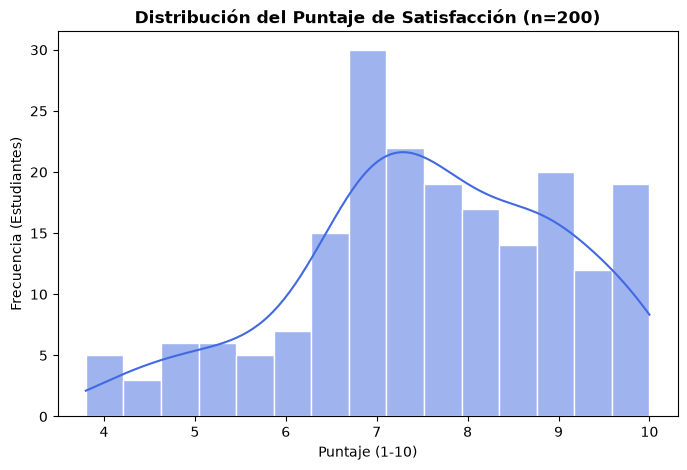

=== Momentos Calculados con NumPy ===
Media muestral: 7.58 puntos
Varianza muestral: 2.17


In [3]:
# Visualización del Histograma
plt.figure(figsize=(8, 5))
sns.histplot(df['Puntaje_satisfaccion'], bins=15, kde=True, color='royalblue', edgecolor='white')
plt.title('Distribución del Puntaje de Satisfacción (n=200)', fontweight='bold')
plt.xlabel('Puntaje (1-10)')
plt.ylabel('Frecuencia (Estudiantes)')
plt.show()

# Cálculos con NumPy
media_np = np.mean(df['Puntaje_satisfaccion'])
# ddof=1 para obtener la varianza muestral insesgada
var_np = np.var(df['Puntaje_satisfaccion'], ddof=1) 

print("=== Momentos Calculados con NumPy ===")
print(f"Media muestral: {media_np:.2f} puntos")
print(f"Varianza muestral: {var_np:.2f}")

### Interpretación de la Distribución
Visualmente, el histograma y la curva KDE revelan que los datos siguen una distribución con forma de campana que se aproxima a una distribución normal. La acumulación central alrededor de los 7.5 puntos es clara. Sin embargo, existe una ligerísima asimetría en la cola derecha porque el puntaje está acotado por un límite natural duro en la escala (10 puntos máximos).

Para propósitos inferenciales, al poseer una muestra generosa ($n=200 > 30$), el Teorema del Límite Central (TLC) nos asegura que la distribución de la media muestral tenderá fuertemente hacia la normalidad, lo que nos permite usar pruebas paramétricas clásicas sin problemas.

## 3. Intervalo de confianza
Dado que la desviación estándar de la población total (el universo de clientes) es desconocida, estimaremos el intervalo de confianza al 95% usando la desviación estándar muestral ($s$) y la distribución t-Student.

In [4]:
n_obs = len(df)
s = df['Puntaje_satisfaccion'].std(ddof=1)
alpha = 0.05
grados_lib = n_obs - 1

# Obtener valor crítico t
t_critico = stats.t.ppf(1 - alpha/2, df=grados_lib)

# Cálculo del error estándar y el margen de error
error_estandar = s / np.sqrt(n_obs)
margen_error = t_critico * error_estandar

limite_inferior = media_np - margen_error
limite_superior = media_np + margen_error

print("=== Intervalo de Confianza para la Media (95%) ===")
print(f"Puntaje Promedio (x̄): {media_np:.2f}")
print(f"Margen de Error: ±{margen_error:.2f}")
print(f"IC 95%: [{limite_inferior:.2f} , {limite_superior:.2f}]")

=== Intervalo de Confianza para la Media (95%) ===
Puntaje Promedio (x̄): 7.58
Margen de Error: ±0.21
IC 95%: [7.37 , 7.78]


### Significado en el Contexto del Estudio
En términos prácticos para la empresa, el intervalo `[7.37, 7.78]` significa que si repitieran esta encuesta con distintas muestras de 200 estudiantes muchísimas veces, el 95% de las veces el promedio real de satisfacción de toda la plataforma educativa caería dentro de este rango numérico. Nos indica que la estimación es altamente precisa y podemos afirmar con seguridad que el curso goza de una percepción promedio general sólida (por sobre los 7 puntos).

## 4. Prueba de hipótesis
Se desea comprobar estadísticamente si es válido afirmar que "El puntaje promedio de satisfacción es igual a 7".

**Planteamiento de Hipótesis:**
*   $H_0: \mu = 7$ (La satisfacción promedio real de los estudiantes es igual a 7).
*   $H_1: \mu \neq 7$ (La satisfacción promedio real es distinta a 7). 

Esta será una prueba bilateral de una muestra (One-Sample t-test) utilizando un nivel de significancia del 5% ($\alpha = 0.05$).

In [5]:
mu_h0 = 7.0

# Ejecución de la prueba t para una muestra (One-Sample t-test) usando scipy
t_stat, p_valor = stats.ttest_1samp(df['Puntaje_satisfaccion'], popmean=mu_h0)

print("=== Resultados de la Prueba de Hipótesis ===")
print(f"Hipótesis Nula (H0): μ = {mu_h0}")
print(f"Estadístico T calculado: {t_stat:.4f}")
print(f"Valor-p: {p_valor:.4e} (aprox {p_valor:.6f})")

print("\n=== Conclusión Estadística ===")
if p_valor <= 0.05:
    print(f"Como el valor-p ({p_valor:.6f}) es menor que α (0.05), SE RECHAZA la hipótesis nula.")
else:
    print(f"Como el valor-p ({p_valor:.6f}) es mayor que α (0.05), NO SE RECHAZA la hipótesis nula.")

=== Resultados de la Prueba de Hipótesis ===
Hipótesis Nula (H0): μ = 7.0
Estadístico T calculado: 5.5491
Valor-p: 9.0874e-08 (aprox 0.000000)

=== Conclusión Estadística ===
Como el valor-p (0.000000) es menor que α (0.05), SE RECHAZA la hipótesis nula.


### Interpretación para la Empresa
La evidencia empírica rechaza fuertemente la idea de que la satisfacción promedio es de un simple 7. Para los directivos, esto es una noticia excelente: significa que el nivel de satisfacción de 7.58 puntos obtenido en esta muestra no fue casualidad ni azar estadístico. El nuevo curso online en verdad superó significativamente la marca de 7 puntos impuesta para la evaluación, consolidándose como un éxito verificable en la plataforma.

## 5. Reflexión final
La estadística inferencial trasciende el simple conteo de datos del pasado; otorga a la empresa un escudo matemático contra el azar. Permite escalar hallazgos de una muestra pequeña a decisiones de inversión millonarias (como mantener o modificar este curso en línea) con grados de certeza cuantificables, transformando datos aislados en estrategias corporativas confiables y minimizando drásticamente los riesgos de los falsos positivos empresariales.